# CardioIA — Fase 4 / Cap 1 · Ir Além 1
## Ética e Governança em Visão Computacional — Análise de Vieses e Fairness

**Autor:** Carlos Mário Vieira de Melo Filho — RM563769

Objetivo: identificar limitações do dataset (desbalanceamento, representatividade)
e aplicar **métricas de fairness** para verificar se o modelo trata subgrupos de
forma equitativa. Usamos como eixo sensível o **subtipo de pneumonia**
(bacteriana × viral), extraído do nome dos arquivos do dataset Kermany.

> Pré-requisito: ter treinado os modelos (`make train`) — usamos o Transfer
> Learning (VGG16) salvo em `models/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, fairness, inference, preprocessing

config.DOCS_DIR.mkdir(exist_ok=True)

### 1. Limitações do dataset

**Desbalanceamento (origem):** o dataset Kermany original é desbalanceado —
aproximadamente **3:1** a favor de PNEUMONIA — e o split de validação oficial tem
apenas **16 imagens**. Mitigamos isso na Parte 1 com um subset **balanceado**
(50/50 NORMAL/PNEUMONIA), evitando que a acurácia fosse inflada pela classe
majoritária.

**Representatividade (limitação importante):** as imagens vêm de **pacientes
pediátricos (1 a 5 anos)** de um único centro (Guangzhou, China). Portanto o
modelo **não** representa a população adulta, idosa ou outras regiões/equipamentos.
Qualquer uso fora desse contexto exige novo dataset e revalidação.

**Viés intra-classe:** dentro de PNEUMONIA há dois subtipos (bacteriana e viral),
também desbalanceados — o que motiva a análise de fairness a seguir.

Abaixo, a composição por subgrupo no subset utilizado.

In [2]:
linhas = []
for split in ['train', 'val', 'test']:
    for classe in config.CLASSES:
        pasta = config.SUBSET_DIR / split / classe
        for caminho in pasta.glob('*'):
            linhas.append({'split': split, 'classe': classe,
                           'subgrupo': fairness.subtipo_pneumonia(caminho)})
comp = pd.DataFrame(linhas)
print(pd.crosstab(comp['split'], comp['subgrupo']))

subgrupo  bacteriana  normal  viral
split                              
test              58     100     42
train            268     400    132
val               63     100     37


### 2. Predições do modelo no conjunto de teste

Rodamos o modelo de Transfer Learning em cada imagem de teste, guardando o
rótulo real, a predição e o subgrupo (para a análise por grupo).

In [3]:
modelo = inference.carregar_modelo('transfer')

registros = []
for classe in config.CLASSES:
    y = 1 if classe == 'PNEUMONIA' else 0
    for caminho in (config.SUBSET_DIR / 'test' / classe).glob('*'):
        batch = preprocessing.preprocess_single(caminho)
        prob = float(modelo.predict(batch, verbose=0).ravel()[0])
        registros.append({
            'arquivo': caminho.name,
            'y_true': y,
            'y_pred': int(prob >= 0.5),
            'prob_pneumonia': prob,
            'subgrupo': fairness.subtipo_pneumonia(caminho),
        })
df = pd.DataFrame(registros)
print('Total avaliado:', len(df))
df.head()

Total avaliado: 200


,arquivo,y_true,y_pred,prob_pneumonia,subgrupo
0,NORMAL2-IM-1038-0001.jpeg,0,0,0.380722,normal
1,NORMAL2-IM-0875-0001.jpeg,0,0,0.368545,normal
2,NORMAL2-IM-0102-0001.jpeg,0,0,0.410922,normal
3,NORMAL2-IM-0684-0001-0001.jpeg,0,0,0.445301,normal
4,IM-0540-0001.jpeg,0,0,0.398300,normal


### 3. Métricas por subgrupo

Foco no **recall (sensibilidade)** dentro da classe PNEUMONIA, separando
**bacteriana × viral**. Em saúde, o **falso negativo** (FNR) é o erro mais grave —
deixar de detectar uma pneumonia real.

In [4]:
metr = fairness.metricas_por_grupo(df['y_true'].values, df['y_pred'].values, df['subgrupo'].values)
tabela = pd.DataFrame(metr).T
print(tabela.round(3))

                n  acuracia  taxa_positivos_previstos  recall    fnr
bacteriana   58.0     0.810                     0.810   0.810  0.190
normal      100.0     0.940                     0.060     NaN    NaN
viral        42.0     0.738                     0.738   0.738  0.262


In [5]:
# Subgrupos relevantes para fairness = dentro da classe PNEUMONIA (bacteriana x viral).
recalls = {g: m['recall'] for g, m in metr.items() if 'recall' in m}
eod = fairness.diferenca_de_oportunidade(recalls)
razao_recall = fairness.impacto_desigual(recalls)  # regra dos 80% aplicada ao recall

print('Recall por subgrupo:', {g: round(v, 3) for g, v in recalls.items()})
print(f'Equal Opportunity Difference (recall): {eod:.3f}  (0 = paridade perfeita)')
print(f'Razao de recall (menor/maior): {razao_recall:.3f}  (alerta se < 0,80)')

# Nota: NAO usamos demographic parity sobre TODOS os grupos, pois as taxas-base
# diferem legitimamente por condicao clinica (um paciente NORMAL DEVE ter baixa
# taxa de 'positivo'). O criterio adequado e equal opportunity (paridade de recall).
print()
for g, m in metr.items():
    print(f"  {g:12s} n={int(m['n']):3d}  taxa_positivos_previstos={m['taxa_positivos_previstos']:.3f}")

Recall por subgrupo: {'bacteriana': 0.81, 'viral': 0.738}
Equal Opportunity Difference (recall): 0.072  (0 = paridade perfeita)
Razao de recall (menor/maior): 0.911  (alerta se < 0,80)

  bacteriana   n= 58  taxa_positivos_previstos=0.810
  normal       n=100  taxa_positivos_previstos=0.060
  viral        n= 42  taxa_positivos_previstos=0.738


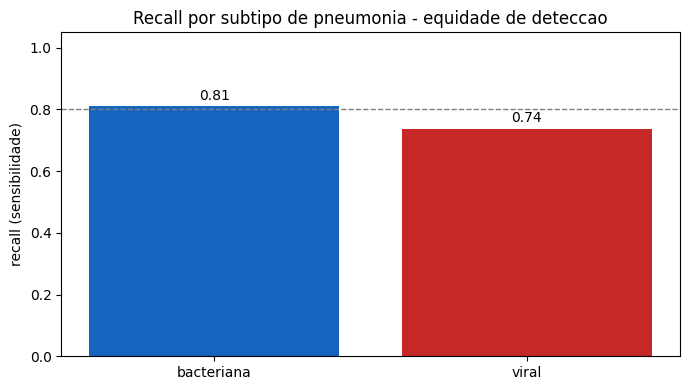

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
grupos = list(recalls.keys())
ax.bar(grupos, [recalls[g] for g in grupos], color=['#1565c0', '#c62828'])
ax.set_ylim(0, 1.05); ax.set_ylabel('recall (sensibilidade)')
ax.set_title('Recall por subtipo de pneumonia - equidade de deteccao')
ax.axhline(0.8, ls='--', color='gray', lw=1)
for i, g in enumerate(grupos):
    ax.text(i, recalls[g] + 0.02, f'{recalls[g]:.2f}', ha='center')
fig.tight_layout(); fig.savefig(config.DOCS_DIR / 'ir_alem1_fairness.png', dpi=120)
plt.show()

### 4. Discussão ética e práticas de mitigação

**Interpretação:** quando o recall da pneumonia **viral** é menor que o da
**bacteriana** (EOD > 0), o modelo é **menos sensível** para esse subgrupo — um viés
clinicamente relevante, pois a pneumonia viral costuma ter padrões radiográficos
mais difusos/sutis, gerando mais falsos negativos para esses pacientes.

**Práticas de mitigação:**

1. **Balanceamento por subgrupo** — equilibrar bacteriana/viral no treino (e não só
   NORMAL/PNEUMONIA).
2. **Reponderação / `class_weight`** — penalizar mais os erros no subgrupo minoritário.
3. **Ajuste de limiar** por sensibilidade clínica — em triagem, baixar o limiar de
   0,5 aumenta o recall (menos falsos negativos), ao custo de mais falsos positivos.
4. **Coleta mais representativa** — incluir adultos/idosos, múltiplos centros e
   equipamentos para reduzir o viés de representatividade.
5. **Governança contínua** — monitorar métricas por subgrupo em produção (drift),
   registrar predições de forma auditável e manter o caráter de **apoio à decisão**
   (humano no circuito), em conformidade com a LGPD.

O relatório completo está em `docs/RELATORIO_IR_ALEM1.md`.